----

----

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [53]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency




### Cargar Dataset

In [54]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [55]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfacción`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [56]:
# Corregir el tipo de dato
# Verificar primero si hay decimales
print("Valores únicos de edad (primeros 10):", df['edad'].head(10).values)

# Convertir a entero
df['edad'] = df['edad'].astype(int)

# Verificar el cambio
print("Tipo de dato después:", df['edad'].dtype)

Valores únicos de edad (primeros 10): [44. 36. 46. 56. 35. 35. 57. 47. 32. 45.]
Tipo de dato después: int64


In [57]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [58]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000



Diagnóstico inicial de variables numéricas

- `edad` — distribución bastante simetrica, no hay valores extremos sospechosos
- `nive_ingreso` - rango amplio (8,000–74,790) con posible presencia de clientes ballena
- `visitas_mes` - Distribución estable
- `compras_mes` - Distribución sesgada a la derecha, la mayoría compra poco.
- `gasto_publicidad_dirigida` - Distribución relativamanete simetrica, con 
outliers en el extremo superior.
- `satisfacción` - Escala 1-5, distribución centrada en valores medios altos.
- `ingreso_anual` - Desviación muy alta, distribución sesgada a la derecha con outliers que distorsionan promedios.



#### Explorar variables binarias

In [59]:
# Verificar que cada columna tenga únicamente dos valores posibles

print('valores posibles de miembro premium:', df['miembro_premium'].nunique())
print(df['miembro_premium'].value_counts())
print()
print('valores posibles de abandono:', df['abandono'].nunique())
print(df['abandono'].value_counts())

valores posibles de miembro premium: 2
0    12911
1     2089
Name: miembro_premium, dtype: int64

valores posibles de abandono: 2
0    12739
1     2261
Name: abandono, dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — Segmento pequeño pero potenciamente de alto valor
- `abandono` — Alrededor del 15% de los clientes han abandonado. Es un nivel moderado de churn

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Validaste que *miembro_premium* y *abandono* tienen dos valores únicos, lo cual confirma que funcionan como variables binarias. Para fortalecer esta revisión, sería conveniente mostrar también la distribución o proporción de cada valor, no solo la cantidad de categorías.


</div>

#### Explorar variables categóricas

In [60]:
# Verificar el número de valores únicos por variable categórica
print('valores tipo de dispositivo:', df['tipo_dispositivo'].nunique())
print('valores region:', df['region'].nunique())

valores tipo de dispositivo: 3
valores region: 4


In [61]:
# Explorar variables categóricas y cómo se distribuyen

print("Distribución de tipo_dispositivo:")
print(df['tipo_dispositivo'].value_counts())

print("\nDistribución de region:")
print(df['region'].value_counts())

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El uso de móvil domina claramente la muestra, lo que sugiere que la mayoría de interacciones ocurren en dispositivos móviles. Escritorio aun representa un cuarto de los usuarios y Tablet es minoritario
- `region` - La distribución es relativamente equilibrada, aunque el norte concentra la mayor proporción de clientes. El este es el segmento más pequeño lo que podria indicar menor captación en esta zona.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Has revisado correctamente las variables categóricas *tipo_dispositivo* y *region*, mostrando tanto el número de categorías como su distribución. Esto permite entender bien la composición de los segmentos antes de pasar a asociaciones o comparaciones.


</div>

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

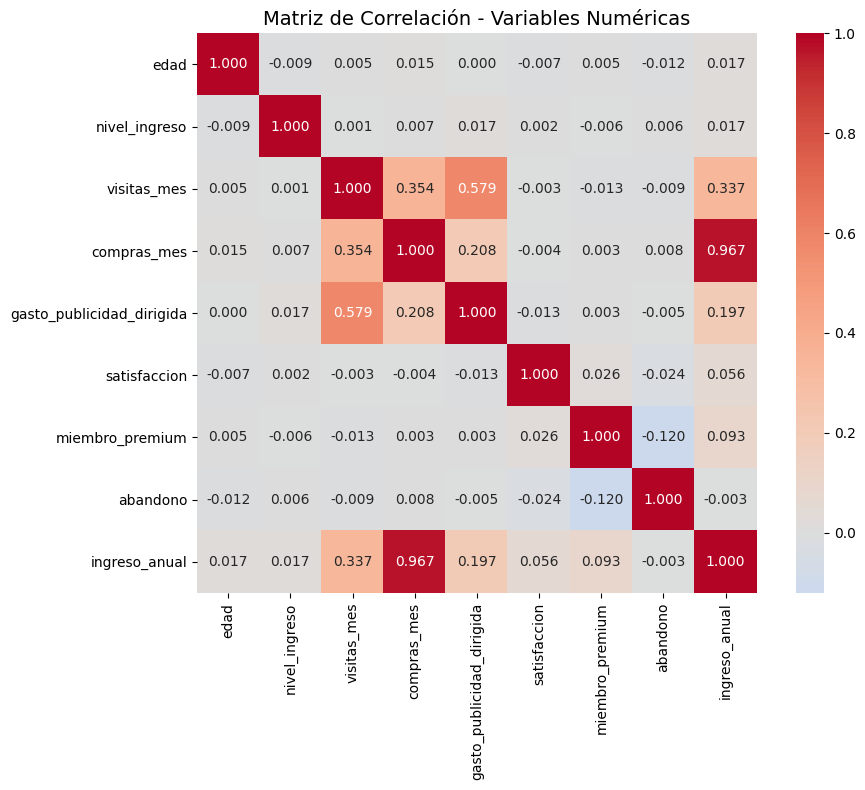

In [62]:
# Visualizar la matriz de correlación para identificar relaciones
df_corr = df.corr()
    
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, 
            annot=True,           # Mostrar valores numéricos
            cmap='coolwarm',      # Esquema de colores
            center=0,             # Centrar en 0
            square=True,          # Celdas cuadradas
            fmt='.3f')            # Formato de 3 decimales

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Observaciones generales (Heatmap)  
El bloque de comportamiento transaccional (visitas, compras, ingresos, publicidad) muestra correlaciones entre sí, con distintas intensidades.

Las variables demográficas (edad, nivel_ingreso) aparecen prácticamente independientes del resto.

Satisfacción se mantiene aislada, sin relación lineal clara con las demás variables.

El heatmap refleja grupos de variables relacionadas y otras que actúan de manera más autónoma.

Observaciones respecto a `ingreso_anual` con `compras_mes` tienen la correlación más alta y positiva (0.967), ambas variables se mueven casi en paralelo. Con `visitas_mes` presenta una relacion moderada positiva (0.337). 

visitas_mes – gasto_publicidad_dirigida (0.579)  
Relación moderada-alta y positiva.

visitas_mes – compras_mes (0.354)  
Relación moderada y positiva.

edad y nivel_ingreso: tiene coeficientes muy cercanos a cero con todas las demás variables.

satisfacción: presenta correlaciones mínimas con el resto (<0.06).



### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

/tmp/ipykernel_40/2176945389.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  pd.plotting.scatter_matrix(df[columnas_numericas], alpha=0.6, figsize=(15, 12), ax=axes)


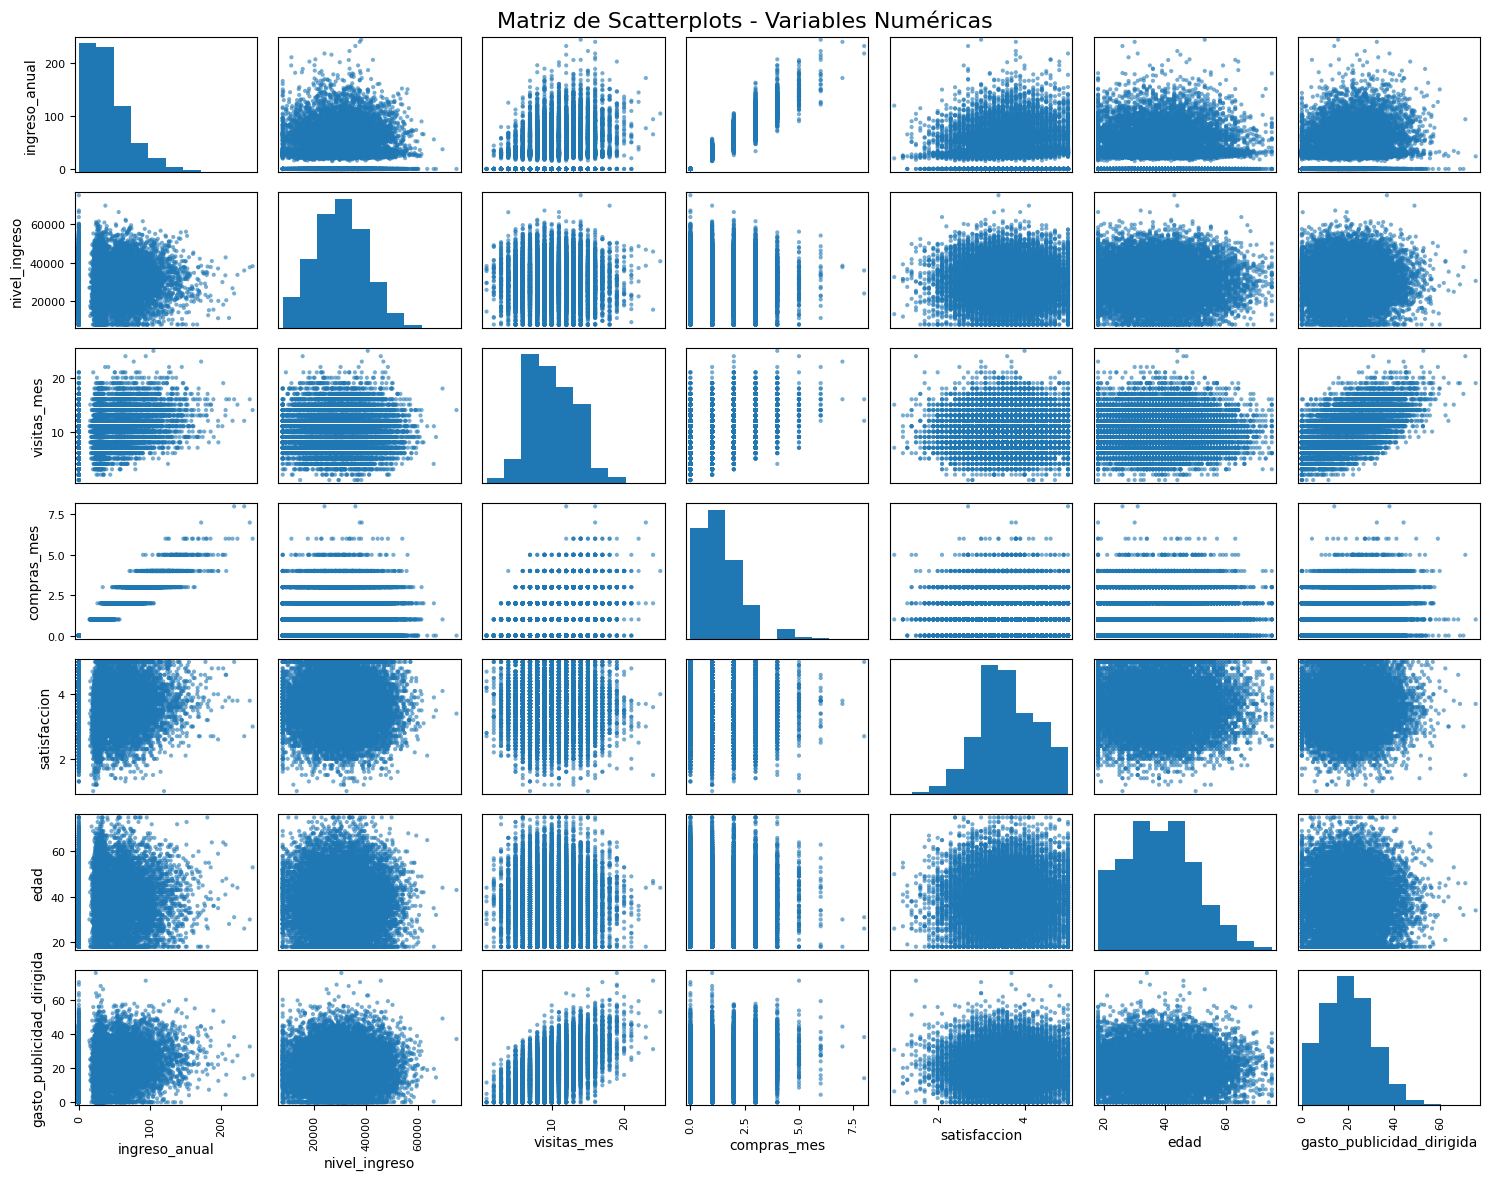

In [63]:
# Crear matriz de scatterplots
fig, axes = plt.subplots(figsize=(15, 12))
pd.plotting.scatter_matrix(df[columnas_numericas], alpha=0.6, figsize=(15, 12), ax=axes)
plt.suptitle('Matriz de Scatterplots - Variables Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

Se observa que visitas_mes y gasto_publicidad_dirigida muestran una relacion lineal muy marcada, lo mismo para  compras_mes e ingreso_anual, visitas_mes y compras_mes muestran nube con ligera pendiente positiva aunque con dispersión.

### Scatterplot para pares clave

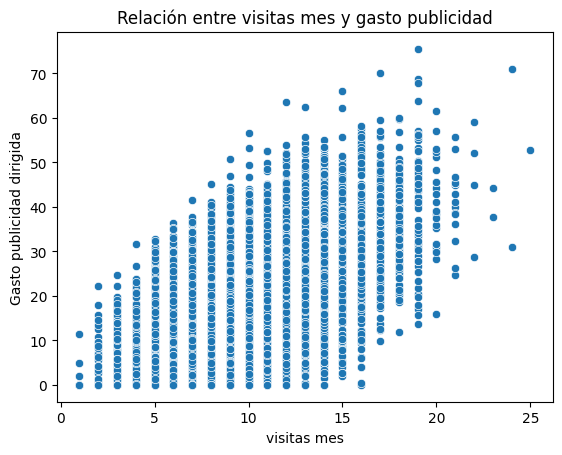

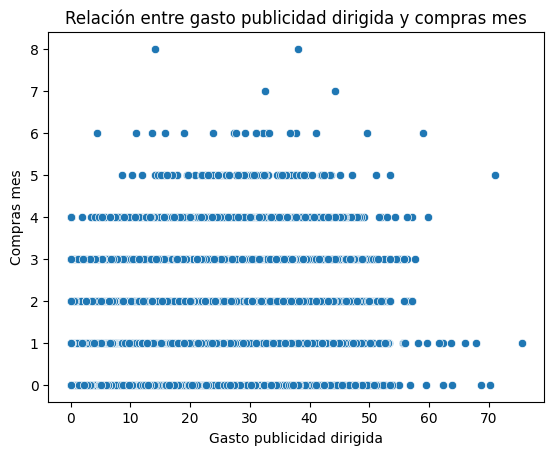

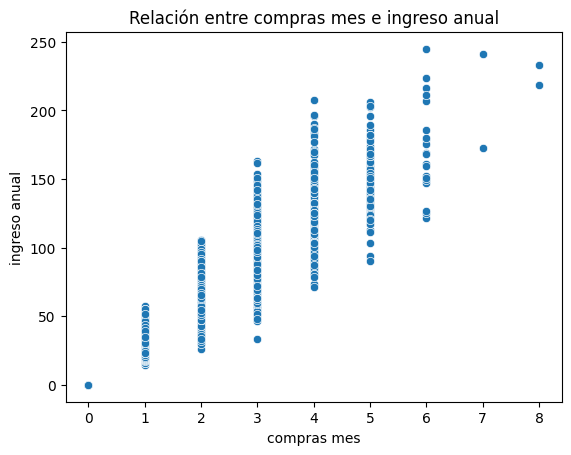

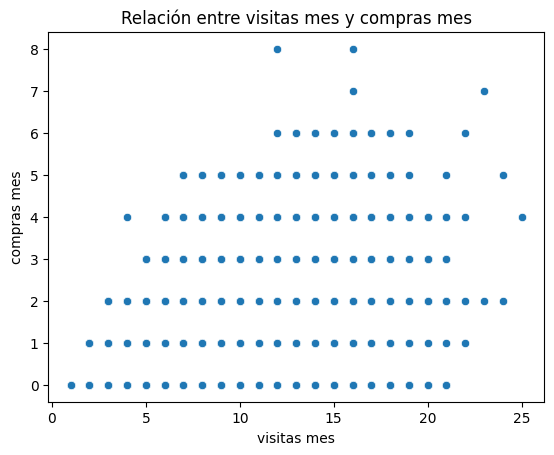

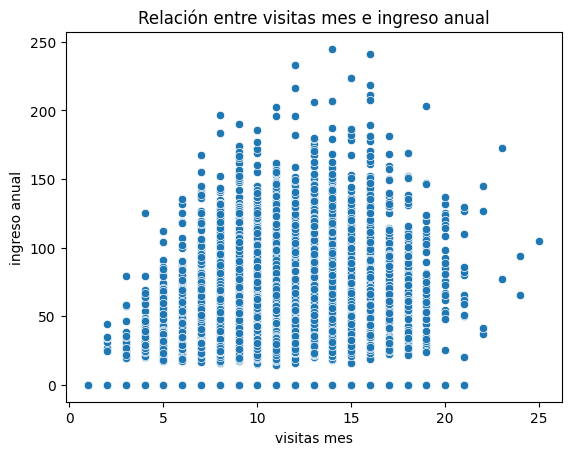

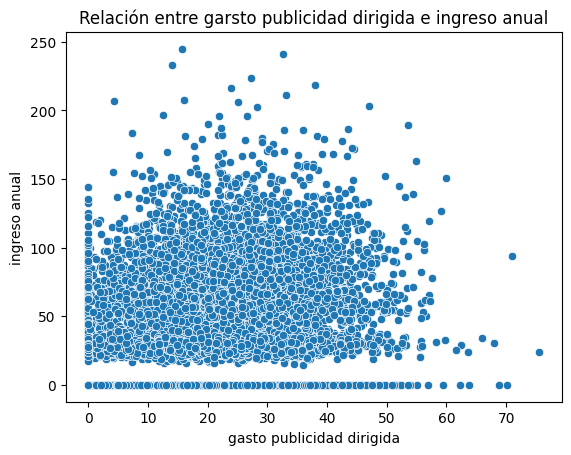

In [64]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x="visitas_mes", y="gasto_publicidad_dirigida")

plt.title("Relación entre visitas mes y gasto publicidad")
plt.xlabel("visitas mes")
plt.ylabel("Gasto publicidad dirigida")
plt.show()

sns.scatterplot(data=df,x="gasto_publicidad_dirigida", y="compras_mes")

plt.title("Relación entre gasto publicidad dirigida y compras mes")
plt.xlabel("Gasto publicidad dirigida")
plt.ylabel("Compras mes")
plt.show()

sns.scatterplot(data=df,x="compras_mes", y="ingreso_anual")

plt.title("Relación entre compras mes e ingreso anual")
plt.xlabel("compras mes")
plt.ylabel("ingreso anual")
plt.show()

sns.scatterplot(data=df,x="visitas_mes", y="compras_mes")

plt.title("Relación entre visitas mes y compras mes")
plt.xlabel("visitas mes")
plt.ylabel("compras mes")
plt.show()


sns.scatterplot(data=df,x="visitas_mes", y="ingreso_anual")

plt.title("Relación entre visitas mes e ingreso anual")
plt.xlabel("visitas mes")
plt.ylabel("ingreso anual")
plt.show()

sns.scatterplot(data=df,x="gasto_publicidad_dirigida", y="ingreso_anual")

plt.title("Relación entre garsto publicidad dirigida e ingreso anual")
plt.xlabel("gasto publicidad dirigida")
plt.ylabel("ingreso anual")
plt.show()


Observaciones iniciales (Scatterplot)

**'visitas_mes' vs 'gasto_publicidad_dirigida'**
- Dirección positiva: a medida que aumentan las visitas mensuales, también tienden a aumentar los valores de gasto en publicidad.
- Dispersión: aunque hay una tendencia ascendente, los puntos están bastante dispersos, lo que indica que no siempre un mayor gasto coincide con más visitas.

**'gasto_publicidad_dirigida' vs 'compras_mes'**
- Dirección positiva: la nube de puntos sugiere una relación débil o poco estructurada entre ambas variables; no se aprecia una pendiente definida.
- El gráfico refleja una asociación débil entre gasto en publicidad dirigida y número de compras mensuales, con predominio de clientes de baja compra en todos los niveles de gasto y algunos casos aislados con mayor actividad.

**'compras_mes' vs 'ingreso_anual'**

- Dirección  positiva: conforme aumentan las compras mensuales, también se incrementan los valores de ingreso anual. La nube de puntos muestra una clara pendiente ascendente.
- El gráfico refleja una asociación fuerte y positiva entre ambas variables, con concentración en clientes de baja frecuencia de compra y algunos grupos minoritarios con ingresos muy altos.

**'visitas_mes' vs 'compras_mes'**
- Dirección positiva: conforme aumentan las visitas mensuales, también tienden a aumentar las compras mensuales. La nube de puntos sugiere una relación ascendente.
- El gráfico refleja una asociación positiva moderada entre visitas y compras, con fuerte concentración en clientes de baja conversión y unos pocos casos de alto rendimiento.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [65]:
# Calcular correlación entre variables relevantes

print("Pearson:")
correlacion_visitas_publicidad = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'])
print(f"Correlación visitas_mes vs gasto_publicidad_dirigida: {correlacion_visitas_publicidad:.3f}")

correlacion_visitas_publicidad = df['visitas_mes'].corr(df['ingreso_anual'])
print(f"Correlación visitas_mes vs ingreso_anual: {correlacion_visitas_publicidad:.3f}")

correlacion_visitas_publicidad = df['gasto_publicidad_dirigida'].corr(df['compras_mes'])
print(f"Correlación gasto_publicidad_dirigida vs compras_mes: {correlacion_visitas_publicidad:.3f}")


correlacion_visitas_publicidad = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'])
print(f"Correlación gasto_publicidad_dirigida vs ingreso_anual: {correlacion_visitas_publicidad:.3f}")


correlacion_compras_ingreso = df['compras_mes'].corr(df['ingreso_anual'])
print(f"Correlación compras_mes vs ingreso_anual: {correlacion_compras_ingreso:.3f}")

correlacion_visitas_compras = df['visitas_mes'].corr(df['compras_mes'])
print(f"Correlación visitas_mes vs compras_mes: {correlacion_visitas_compras:.3f}")

print("Spearman:")

correlacion_visitas_publicidad = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'],method='spearman')
print(f"Correlación visitas_mes vs gasto_publicidad_dirigida: {correlacion_visitas_publicidad:.3f}")

correlacion_visitas_publicidad = df['visitas_mes'].corr(df['ingreso_anual'],method='spearman')
print(f"Correlación visitas_mes vs ingreso_anual: {correlacion_visitas_publicidad:.3f}")

correlacion_visitas_publicidad = df['gasto_publicidad_dirigida'].corr(df['compras_mes'],method='spearman')
print(f"Correlación gasto_publicidad_dirigida vs compras_mes: {correlacion_visitas_publicidad:.3f}")

correlacion_visitas_publicidad = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'],method='spearman')
print(f"Correlación gasto_publicidad_dirigida vs ingreso_anual: {correlacion_visitas_publicidad:.3f}")

correlacion_compras_ingreso = df['compras_mes'].corr(df['ingreso_anual'],method='spearman')
print(f"Correlación compras_mes vs ingreso_anual: {correlacion_compras_ingreso:.3f}")

correlacion_visitas_compras = df['visitas_mes'].corr(df['compras_mes'],method='spearman')
print(f"Correlación visitas_mes vs compras_mes: {correlacion_visitas_compras:.3f}")

Pearson:
Correlación visitas_mes vs gasto_publicidad_dirigida: 0.579
Correlación visitas_mes vs ingreso_anual: 0.337
Correlación gasto_publicidad_dirigida vs compras_mes: 0.208
Correlación gasto_publicidad_dirigida vs ingreso_anual: 0.197
Correlación compras_mes vs ingreso_anual: 0.967
Correlación visitas_mes vs compras_mes: 0.354
Spearman:
Correlación visitas_mes vs gasto_publicidad_dirigida: 0.559
Correlación visitas_mes vs ingreso_anual: 0.321
Correlación gasto_publicidad_dirigida vs compras_mes: 0.193
Correlación gasto_publicidad_dirigida vs ingreso_anual: 0.185
Correlación compras_mes vs ingreso_anual: 0.967
Correlación visitas_mes vs compras_mes: 0.333


Observaciones de correlación


**'visitas_mes' vs 'gasto_publicidad_dirigida'**
- Correlación positiva moderada-alta. Indica que ambas variables tienden a aumentar juntas con cierta consistencia.
  
**'gasto_publicidad_dirigida' vs 'compras_mes'**
- Correlacion positiva y debil pero consistente

**'compras_mes' vs 'ingreso_anual'**
- Correlación positiva muy fuerte. Los valores de ambas variables se mueven casi en paralelo, mostrando una asociación lineal clara.

**'visitas_mes' vs 'compras_mes'**
- Correlación positiva moderada. Sugiere que existe una relación ascendente, aunque con mayor dispersión que en los casos anteriores.

### Punto-biserial

In [66]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr 

def corr_point_biserial(df, col_binaria, columnas_numericas):
    
        for col in columnas_numericas:
            coef, p_value = pointbiserialr(df[col_binaria],df[col])

            print(f"\nCorrelacion entre: {col_binaria} y {col}")
            print(f"Point-Biserial: {coef:.4f}")

columnas_numericas = ["ingreso_anual","nivel_ingreso","visitas_mes","compras_mes", "satisfaccion","edad","gasto_publicidad_dirigida"]
corr_point_biserial(df,"miembro_premium", columnas_numericas)
corr_point_biserial(df,"abandono", columnas_numericas)


Correlacion entre: miembro_premium y ingreso_anual
Point-Biserial: 0.0931

Correlacion entre: miembro_premium y nivel_ingreso
Point-Biserial: -0.0056

Correlacion entre: miembro_premium y visitas_mes
Point-Biserial: -0.0127

Correlacion entre: miembro_premium y compras_mes
Point-Biserial: 0.0034

Correlacion entre: miembro_premium y satisfaccion
Point-Biserial: 0.0257

Correlacion entre: miembro_premium y edad
Point-Biserial: 0.0046

Correlacion entre: miembro_premium y gasto_publicidad_dirigida
Point-Biserial: 0.0027

Correlacion entre: abandono y ingreso_anual
Point-Biserial: -0.0028

Correlacion entre: abandono y nivel_ingreso
Point-Biserial: 0.0059

Correlacion entre: abandono y visitas_mes
Point-Biserial: -0.0089

Correlacion entre: abandono y compras_mes
Point-Biserial: 0.0083

Correlacion entre: abandono y satisfaccion
Point-Biserial: -0.0238

Correlacion entre: abandono y edad
Point-Biserial: -0.0115

Correlacion entre: abandono y gasto_publicidad_dirigida
Point-Biserial: -0.0

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium y ingreso_anual**
- Tiende a una relacion debil aunque positiva pero es la más alta

**miembro_premium y nivel_ingreso**
- Relación tiende a ser nula pero negativa 

**miembro_premium y visitas_mes**
- Relación tiende a ser casi nula pero negativa

**miembro_premium y compras_mes**
- Relación tiende a ser nula pero positiva
  
**miembro_premium y satisfaccion**
- Relación tiende a ser muy debil

**miembro_premium y edad**
- Relación tiende a ser casi nula 

**miembro_premium y gasto_publicidad_dirigida**
- Relación tiende a ser nula

**abandono y ingreso_anual**
- Relación tiende a ser nula y negativa 
  
**abandono y nivel_ingreso**
- Relación tiende a ser nula 

**abandono y visitas_mes**
- Relación tiende a ser nula pero negativa

**abandono y compras_mes**
- Relación tiende a ser nula pero positiva 
  
**abandono y satisfaccion**
- Relación tiende a ser muy debil y negativa

**abandono y edad**
- Relación tiende a ser muy debil y negativa

**abandono y gasto_publicidad_dirigida**
- Relación tiende a ser casi nula y negativa

### V de Cramér

In [67]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])
    
    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    
    return v


In [68]:
# Aplicar V de Cramér en variables relevantes
print("V de Cramér tipo_dispositivo vs region:",cramer_v(df,"tipo_dispositivo","region"))
print("V de Cramér miembro_premium vs tipo_dispositivos:",cramer_v(df,"miembro_premium","tipo_dispositivo"))
print("V de Cramér abandono vs tipo_dispositivo:",cramer_v(df,"abandono","tipo_dispositivo"))
print("V de Cramér miembro_premium vs region:",cramer_v(df,"miembro_premium","region"))
print("V de Cramér abandono vs region:",cramer_v(df,"abandono","region"))

V de Cramér tipo_dispositivo vs region: 0.012378338407739397
V de Cramér miembro_premium vs tipo_dispositivos: 0.019725434455421662
V de Cramér abandono vs tipo_dispositivo: 0.007245190431994803
V de Cramér miembro_premium vs region: 0.012574183027958333
V de Cramér abandono vs region: 0.015429712175030079


Observaciones V de Cramér

V de Cramér tipo_dispositivo vs region: Existe una relación muy débil  
V de Cramér miembro_premium vs tipo_dispositivos: Existe una relación débil
V de Cramér abandono vs tipo_dispositivo: Relacion practicamente nula
V de Cramér miembro_premium vs region: Existe una relación muy baja
V de Cramér abandono vs region: Existe una relación débil

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — compras mes e ingreso anual 

**Evidencia visual:** Scatterplot y heatmap  
**Evidencia numérica:** Pearson: 0.967

**Interpretación**  
- Los clientes que compran más frecuentemente están fuertemente asociados con mayores ingresos anuales

**No podemos afirmar**  
- Que más compras causan directamente más ingresos
- Que el ingreso determina la frecuencia de compra

**Implicación de negocio**  
- Frecuencia de compra es un predictor muy confiable del valor del cliente
- Estrategias para aumentar frecuencia podrían impactar significativamente los ingresos
- Los clientes de alta frecuencia son el segmento más valioso



### Hallazgo 2 — visitas mes y ingreso anual 

**Evidencia visual:** Scatterplot y heatmap  
**Evidencia numérica:** Spearman: 0.321

**Interpretación**  
- Los clientes que visitan más frecuentemente la plataforma están asociados con mayores ingresos anuales
- Existe un patrón consistente: mayor actividad de navegación se relaciona con mayor valor económico
  
**No podemos afirmar**  
- Que más visitas causen directamente más ingresos
- Que aumentar artificialmente las visitas garantice más ingresos
- Que la frecuencia de visita sea el factor determinante del valor del cliente
    
**Implicación de negocio**  

- Segmentación de valor: Los usuarios frecuentes representan un segmento de mayor potencial económico
- Optimización de engagement: Mejorar la experiencia puede retener a usuarios valiosos
- Predicción temprana: La frecuencia de visitas puede ser un indicador temprano del valor del cliente




### Hallazgo 2 — gasto publicidad dirigida e ingreso anual 

**Evidencia visual:** Scatterplot y heatmap  
**Evidencia numérica:** Spearman: 0.185

**Interpretación**  
- La relación es positiva, lo que significa que a mayor gasto en publicidad dirigida, tiende a haber un mayor ingreso anual, aunque esta asociación es limitada.
  
**No podemos afirmar**  
- Que más gasto en publicidad cause directamente más ingresos
    
**Implicación de negocio**  

- Segmentación de valor: Los usuarios frecuentes representan un segmento de mayor potencial económico
- Optimización de engagement: Mejorar la experiencia puede retener a usuarios valiosos
- Predicción temprana: La frecuencia de visitas puede ser un indicador temprano del valor del cliente


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Variables no controladas (campañas, estacionalidad, promociones)
- Paradoja de Simpson: Las correlaciones pueden cambiar al segmentar por subgrupos

### **Próximos pasos** 

Probar segmentación adicional

1. Segmentación Demográfico-Tecnológica
Combinando edad, tipo_dispositivo y region:

- Jóvenes móviles urbanos
- Adultos escritorio regionales
- Seniors multi-dispositivo
  
Utilidad: Personalización de experiencia y canales de comunicación

2. Segmentación por Eficiencia Publicitaria
Basada en gasto_publicidad_dirigida vs ingreso_anual:

- ROI alto (bajo gasto, alto ingreso)
- ROI medio (gasto proporcional al ingreso)
- ROI bajo (alto gasto, bajo ingreso)
Utilidad: Optimizar asignación de presupuesto publicitario

3. Segmentación por Comportamiento Digital
Basada en visitas_mes y compras_mes:

- Navegadores activos/compradores frecuentes (alta visita + alta compra)
- Navegadores activos/compradores ocasionales (alta visita + baja compra)
- Navegadores ocasionales/compradores frecuentes (baja visita + alta compra)
- Usuarios de baja actividad (baja visita + baja compra)
Utilidad: Entender patrones de conversión y optimizar experiencia